# Lab 2: Exploratory Data Analysis (EDA) and Data Preprocessing





In [1575]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns




# Load the Titanic Dataset

In [1576]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Dataset Structure

In [1577]:
print("Shape   :", df.shape)

Shape   : (891, 15)


In [1578]:
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])


Rows    : 891
Columns : 15


In [1579]:
age = df["age"]

In [1580]:
type(age)

pandas.core.series.Series

In [1581]:
age

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [1582]:
age_df1 = pd.DataFrame(df["age"])
type(age_df1)

pandas.core.frame.DataFrame

In [1583]:
age_df = age.to_frame()

print(type(age_df))

<class 'pandas.core.frame.DataFrame'>


#A Pandas Series is a one-dimensional labeled array that contains a sequence of values along with an index.



#A Pandas DataFrame is a two-dimensional labeled data structure consisting of rows and columns, where each column can contain a different data type.

pd.DataFrame(df["age"])

.to_frame()

In [1584]:
age1=df[["age"]]

In [1585]:
type(age1)

pandas.core.frame.DataFrame

In [1586]:
type(df["age"])

pandas.core.series.Series

In [1587]:
type(df[["age"]])

pandas.core.frame.DataFrame

In [1588]:
type(df.columns)

pandas.core.indexes.base.Index

df.columns is a Pandas Index object.

.tolist() converts it to a normal Python list.

In [1589]:
type(df.columns.tolist())

list

#Series → List

In [1590]:
age_l=df['age']

print(age_l[:10])

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64


In [1591]:
type(age_l)

pandas.core.series.Series

In [1592]:
a=age_l.tolist()

print(a[:10])

[22.0, 38.0, 26.0, 35.0, 35.0, nan, 54.0, 2.0, 27.0, 14.0]


In [1593]:
type(a)

list

In [1594]:
age_list = df["age"].tolist()

print(age_list[:10])

[22.0, 38.0, 26.0, 35.0, 35.0, nan, 54.0, 2.0, 27.0, 14.0]


#loc — label-based selection

loc selects data using labels.

The basic structure is:

df.loc[row, column]


Give me the value from row label 0 and column "age".

In [1595]:
df.loc[4, 'fare']

np.float64(8.05)

In [1596]:
df.loc[0:4] # loc — select multiple rows

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#NOTE : (.loc) , the ending label is generally included.

In [1597]:
df.loc[5:8, ["age", "fare"]]  # select rows and columns

,age,fare
5,NaN,8.4583
6,54.0,51.8625
7,2.0,21.0750
8,27.0,11.1333


#iloc — position-based selection

iloc uses integer positions, not labels.

df.iloc[0, 3]

means:

Give me the value at the first row and fourth column.

Remember Python indexing starts at 0:

position:

0 → first

1 → second

2 → third

3 → fourth


In [1598]:
df.iloc[3, 8]

'First'

#Selecting multiple columns

In [1599]:
df[["age", "fare", "sex"]]

,age,fare,sex
0,22.0,7.2500,male
1,38.0,71.2833,female
2,26.0,7.9250,female
3,35.0,53.1000,female
4,35.0,8.0500,male
...,...,...,...
886,27.0,13.0000,male
887,19.0,30.0000,female
888,NaN,23.4500,female
889,26.0,30.0000,male


#value_counts()

It counts how many times each category occurs.

In [1600]:
df["sex"].value_counts()

,count
sex,
male,577
female,314


In [1601]:
df["embarked"].value_counts()

,count
embarked,
S,644
C,168
Q,77


#unique()

Shows the unique values:

In [1602]:
df["embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

#nunique()

Counts the number of unique values:

In [1603]:
df["embarked"].nunique()

3

#isnull()

Checks whether a value is missing.

In [1604]:
df["age"].isnull()

,age
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,True
889,False


#groupby()

groupby()  is used to divide the data into groups based on a particular column, so that we can perform calculations or analysis separately for each group.

In [1605]:
df.groupby("sex")["fare"].mean()  #Group passengers according to their gender, then calculate the average fare for each group.

,fare
sex,
female,44.479818
male,25.523893


In [1606]:
df.groupby("pclass")["fare"].mean() #average fare for each passenger class.

,fare
pclass,
1,84.154687
2,20.662183
3,13.675550


#groupby() with multiple statistics

In [1607]:
df.groupby("pclass")["fare"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
pclass,,,,
1,84.154687,60.2875,0.0,512.3292
2,20.662183,14.2500,0.0,73.5000
3,13.675550,8.0500,0.0,69.5500


In [1608]:
df.groupby("sex")["survived"].mean() #this can tell us the survival rate by gender

,survived
sex,
female,0.742038
male,0.188908


In [1609]:
type(df)

pandas.core.frame.DataFrame

In [1610]:
columns_list = df.columns.tolist()

print(columns_list)

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [1611]:
df.dtypes


,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [1612]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### Interpreting `info()`

- **Non-Null Count** = number of available values in a column.
- If a dataset has 891 rows but a column has 714 non-null values, then `891 - 714 = 177` values are missing.
- `int64` = integer, `float64` = decimal, `object`/`category` = categorical/text, `bool` = True/False.


In [1613]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [1614]:
df.tail(10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
881,0,3,male,33.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True


#sample()

randomly selects 10 rows.

random_state=42 makes the random selection reproducible.

Without it the selected rows may change each time.

In [1615]:
df.sample(10, random_state=41)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
454,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
624,0,3,male,21.0,0,0,16.1000,S,Third,man,True,NaN,Southampton,no,True
537,1,1,female,30.0,0,0,106.4250,C,First,woman,False,NaN,Cherbourg,yes,True
685,0,2,male,25.0,1,2,41.5792,C,Second,man,True,NaN,Cherbourg,no,False
396,0,3,female,31.0,0,0,7.8542,S,Third,woman,False,NaN,Southampton,no,True
551,0,2,male,27.0,0,0,26.0000,S,Second,man,True,NaN,Southampton,no,True
373,0,1,male,22.0,0,0,135.6333,C,First,man,True,NaN,Cherbourg,no,True
759,1,1,female,33.0,0,0,86.5000,S,First,woman,False,B,Southampton,yes,True
797,1,3,female,31.0,0,0,8.6833,S,Third,woman,False,NaN,Southampton,yes,True
366,1,1,female,60.0,1,0,75.2500,C,First,woman,False,D,Cherbourg,yes,False


In [1616]:
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### `describe()` interpretation

- `count`: non-missing observations
- `mean`: average
- `std`: standard deviation
- `min`: minimum
- `25%`: Q1
- `50%`: median
- `75%`: Q3
- `max`: maximum


In [1617]:

df.describe(include="all")


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Missing Value Analysis

In [1618]:
missing = df.isnull().sum() #sum() counts the True values.
missing


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


#len()

Returns the number of rows.

In [1619]:
len(df)

891

#sort_values()

Sort rows according to a column.

BY Default it uses Ascending order

In [1620]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df)) * 100
}).sort_values("Percentage (%)", ascending =False)

missing_summary


,Missing Values,Percentage (%)
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


### `NaN`

`NaN` represents a missing/unavailable value. It is not the same as zero or `False`.


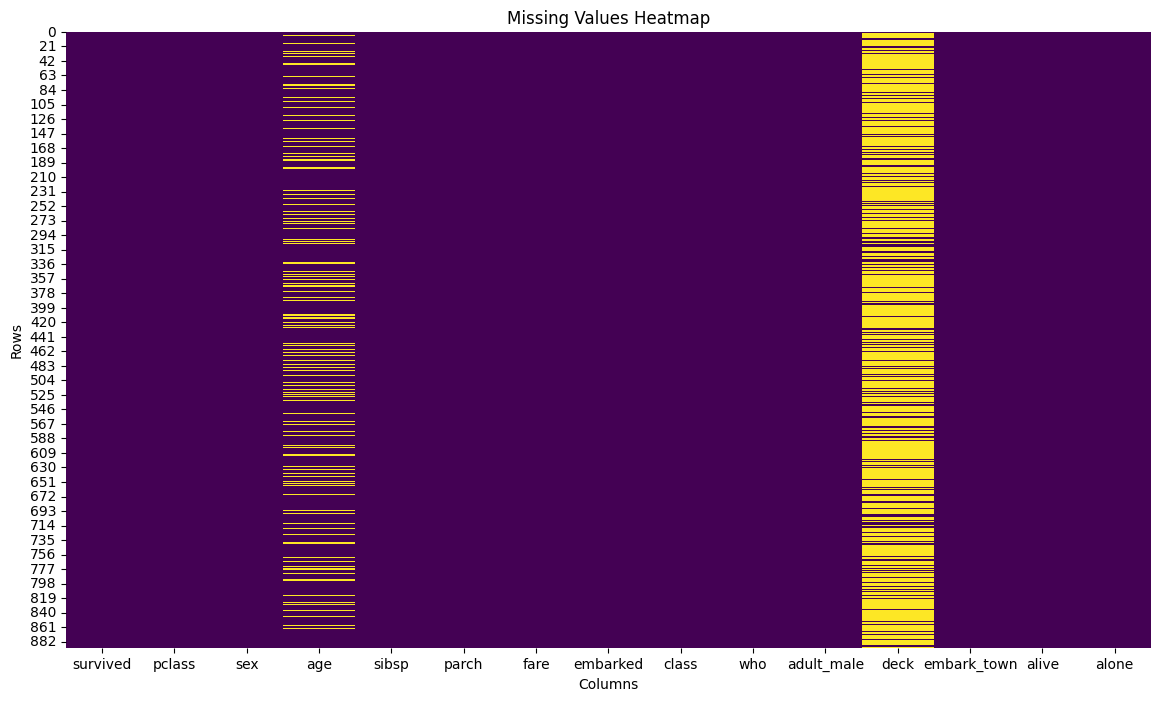

In [1621]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


### `cmap` and `cbar`

- `cmap` = color map; controls the heatmap colors.
- `cbar=True` shows the color-scale legend.
- `cbar=False` hides it. For a simple missing-value map, the legend is often unnecessary.


# Duplicate Analysis

In [1622]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 107


In [1623]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,True
887,False
888,False
889,False


In [1624]:
df.duplicated(keep=False)


,0
0,False
1,False
2,False
3,False
4,True
...,...
886,True
887,False
888,False
889,False


In [1625]:
df[df.duplicated(keep=False)].head(20)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True
29,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
32,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
37,0,3,male,21.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
42,0,3,male,NaN,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True
45,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
46,0,3,male,NaN,1,0,15.5000,Q,Third,man,True,NaN,Queenstown,no,False
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True


In [1626]:
df['age'].describe()

,age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [1627]:
df['age'].value_counts()

,count
age,
24.00,30
22.00,27
18.00,26
28.00,25
30.00,25
...,...
24.50,1
0.67,1
0.42,1


In [1628]:
df[df['age']> 65]['age']

,age
33,66.0
96,71.0
116,70.5
493,71.0
630,80.0
672,70.0
745,70.0
851,74.0


In [1629]:
df[df['age']>=35][['fare','age']]

,fare,age
1,71.2833,38.0
3,53.1000,35.0
4,8.0500,35.0
6,51.8625,54.0
11,26.5500,58.0
...,...,...
865,13.0000,42.0
871,52.5542,47.0
873,9.0000,47.0
879,83.1583,56.0


In [1630]:
df[df['fare']>300]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
258,1,1,female,35.0,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True
679,1,1,male,36.0,0,1,512.3292,C,First,man,True,B,Cherbourg,yes,False
737,1,1,male,35.0,0,0,512.3292,C,First,man,True,B,Cherbourg,yes,True


#Multiple conditions

In [1631]:
df[
    (df["sex"] == "female") &
    (df["age"] > 50)
]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
15,1,2,female,55.0,0,0,16.0000,S,Second,woman,False,NaN,Southampton,yes,True
195,1,1,female,58.0,0,0,146.5208,C,First,woman,False,B,Cherbourg,yes,True
268,1,1,female,58.0,0,1,153.4625,S,First,woman,False,C,Southampton,yes,False
275,1,1,female,63.0,1,0,77.9583,S,First,woman,False,D,Southampton,yes,False
366,1,1,female,60.0,1,0,75.2500,C,First,woman,False,D,Cherbourg,yes,False
483,1,3,female,63.0,0,0,9.5875,S,Third,woman,False,NaN,Southampton,yes,True
496,1,1,female,54.0,1,0,78.2667,C,First,woman,False,D,Cherbourg,yes,False
513,1,1,female,54.0,1,0,59.4000,C,First,woman,False,NaN,Cherbourg,yes,False
571,1,1,female,53.0,2,0,51.4792,S,First,woman,False,C,Southampton,yes,False


In [1632]:
df['fare'].isnull().sum()

np.int64(0)

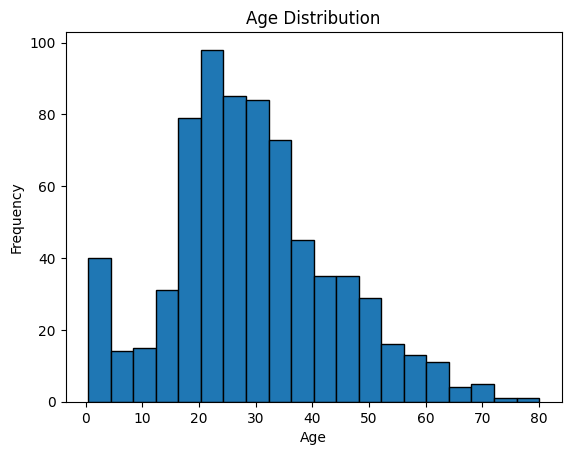

In [1633]:
df['age'].plot(kind='hist', bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

<Axes: >

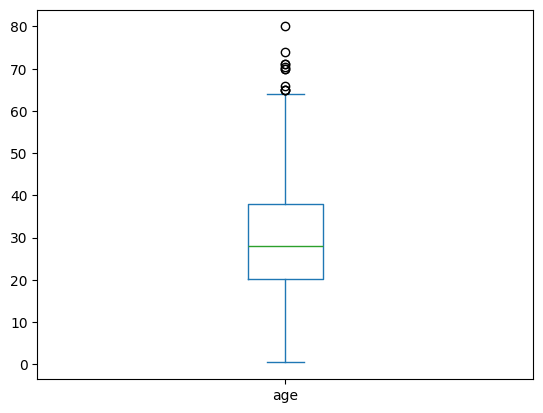

In [1634]:
df['age'].plot(kind='box')

In [1635]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns.to_list()

print("Numerical:", numerical_columns)
print("Categorical:", categorical_columns)


Numerical: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [1636]:
type(categorical_columns)

list

#Seaborn Template



# ==============================
# SEABORN PLOT TEMPLATE
# ==============================


sns.plot_name(

    data=df,

    x="X_COLUMN",

    y="Y_COLUMN",

    hue="GROUP_COLUMN"
)

plt.title("TITLE")

plt.xlabel("X-AXIS LABEL")

plt.ylabel("Y-AXIS LABEL")

plt.legend(title="LEGEND TITLE")

plt.tight_layout()

plt.show()








#2. Matplotlib Template

Matplotlib is slightly different.

Instead of:

sns.boxplot(...)

you generally use functions such as:

plt.plot()

plt.scatter()

plt.bar()

plt.hist()

plt.boxplot()









# ==============================
# MATPLOTLIB PLOT TEMPLATE
# ==============================




plt.plot_name(
    x,
    y
)

plt.title("TITLE")

plt.xlabel("X-AXIS LABEL")

plt.ylabel("Y-AXIS LABEL")

plt.legend()

plt.tight_layout()

plt.show()


#hue specifies the variable whose categories should be represented by different colors in the plot.


#A legend is a guide on a plot that explains what different colors, symbols, or lines represent.


#plt.tight_layout() is used to automatically adjust the spacing of plot elements so that labels, titles, and other elements do not overlap or get cut off.


#loc is a parameter used to specify the location/position of an element in a plot, such as a legend or title.

For example:

plt.legend(loc="upper right")

means:

Place the legend in the upper-right corner of the plot.

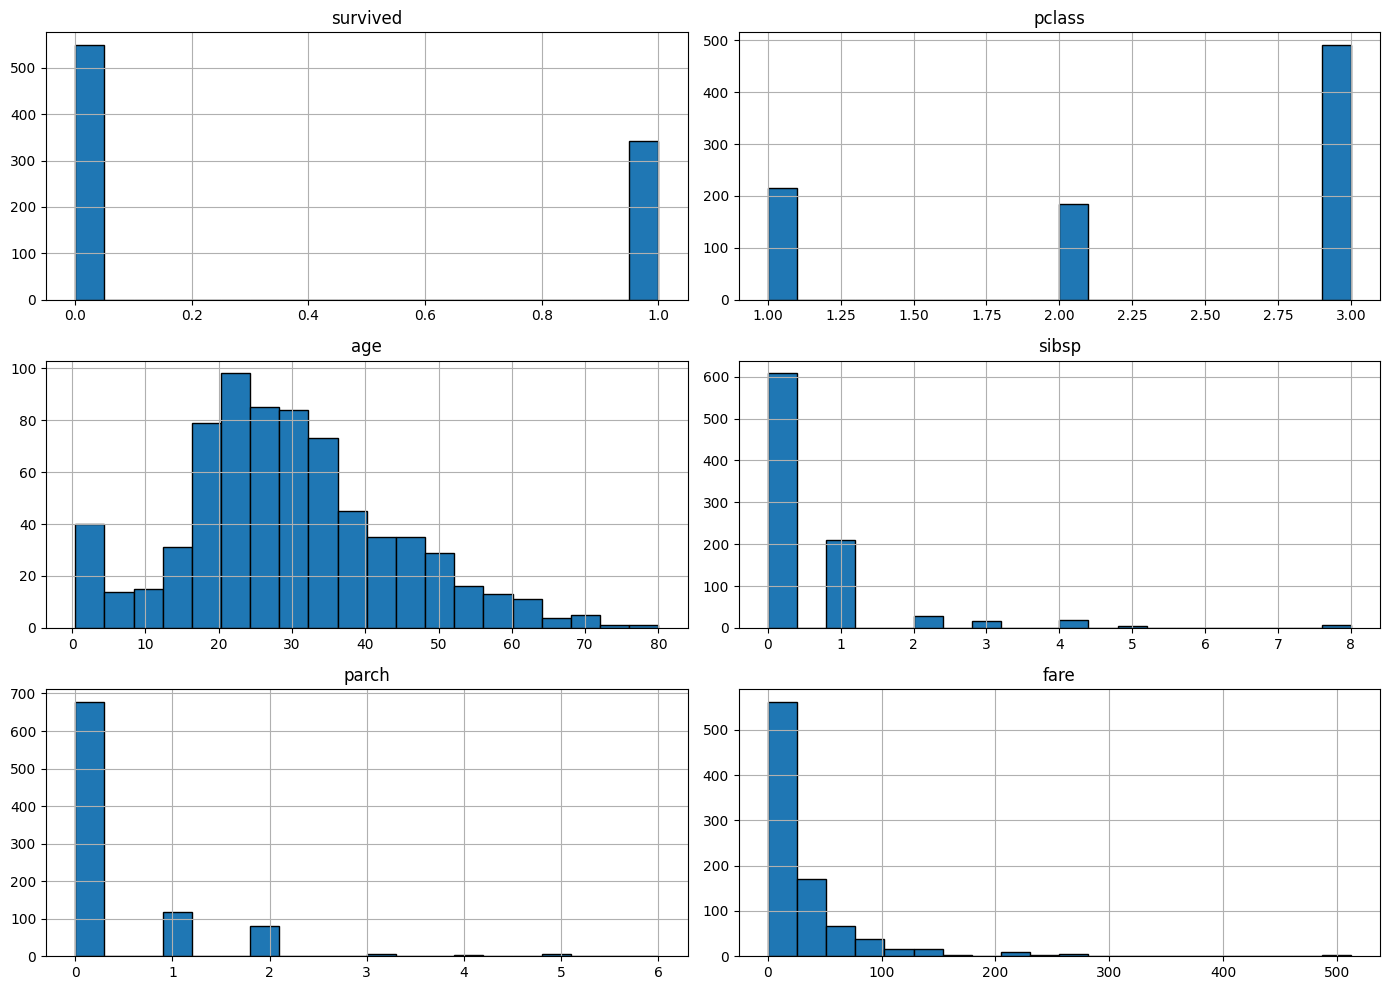

In [1637]:
df[numerical_columns].hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.tight_layout()
plt.show()


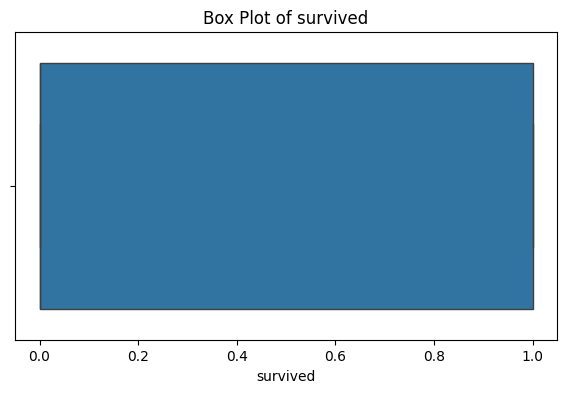

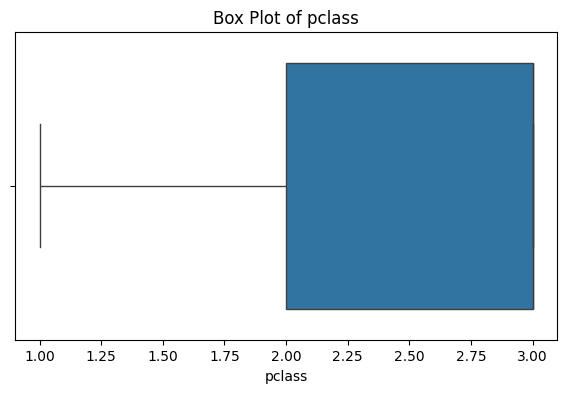

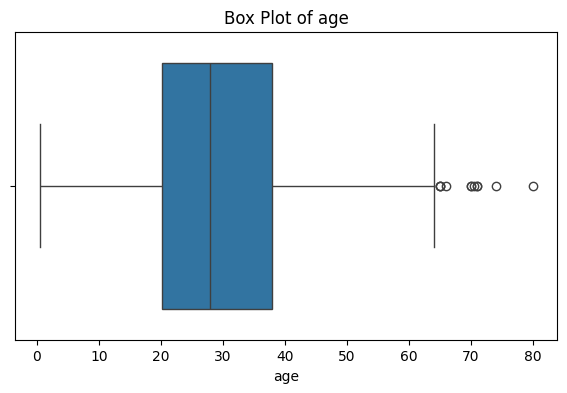

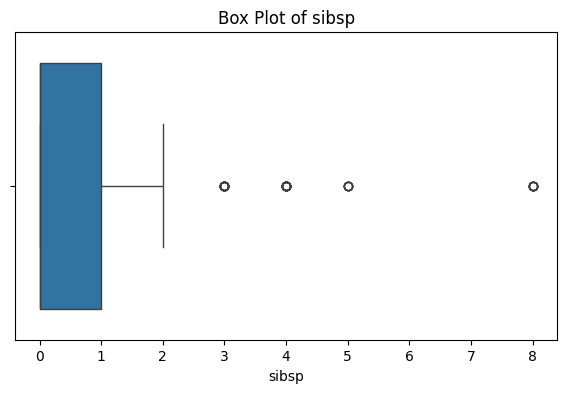

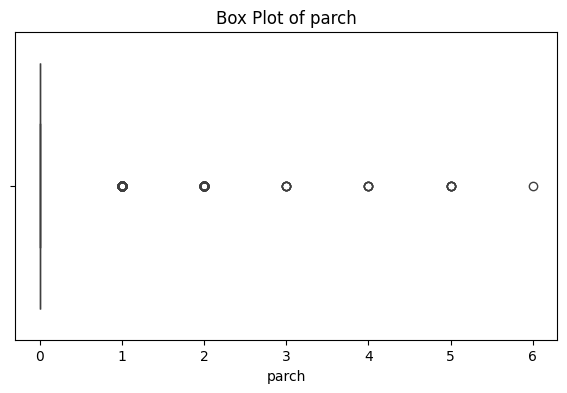

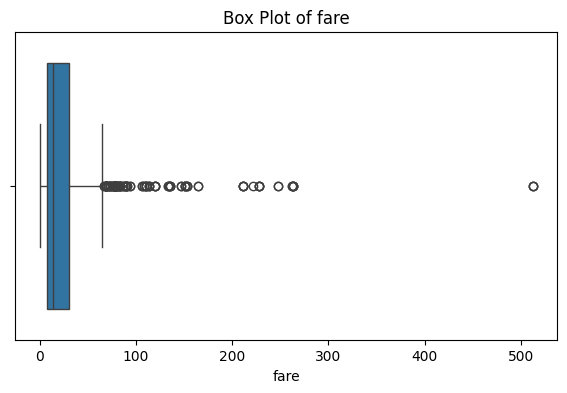

In [1638]:
for column in numerical_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
    plt.show()


## Box plots and outliers

A box plot shows Q1, median, Q3, and whiskers.

```text
IQR = Q3 - Q1

Lower bound = Q1 - 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR
```

Values outside these bounds are **potential outliers**.

An outlier is not automatically an error and should not be deleted without investigation.


In [1639]:
# Example: calculate potential outliers for fare
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)


Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower bound: -26.724
Upper bound: 65.6344


In [1640]:
fare_outliers = df[
    (df["fare"] < lower_bound) |
    (df["fare"] > upper_bound)
]

print("Potential fare outliers:", len(fare_outliers))
fare_outliers[["fare", "pclass", "survived"]].sort_values(
    "fare", ascending=False
).head(20)


Potential fare outliers: 116


,fare,pclass,survived
258,512.3292,1,1
737,512.3292,1,1
679,512.3292,1,1
27,263.0000,1,0
341,263.0000,1,1
438,263.0000,1,0
88,263.0000,1,1
311,262.3750,1,1
742,262.3750,1,1
299,247.5208,1,1


#catagorical columns

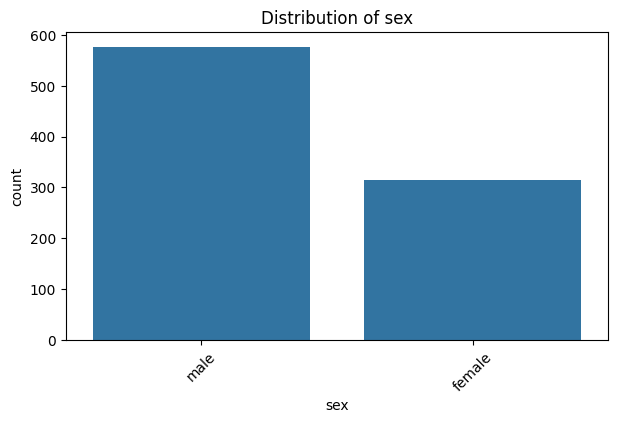

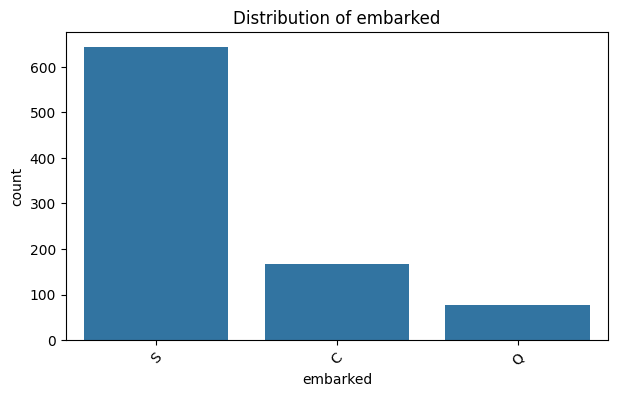

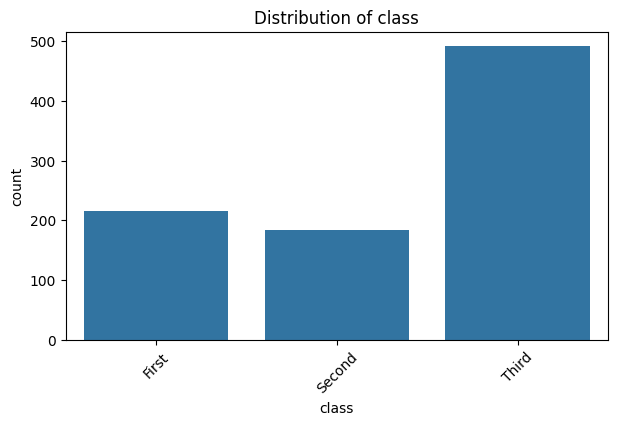

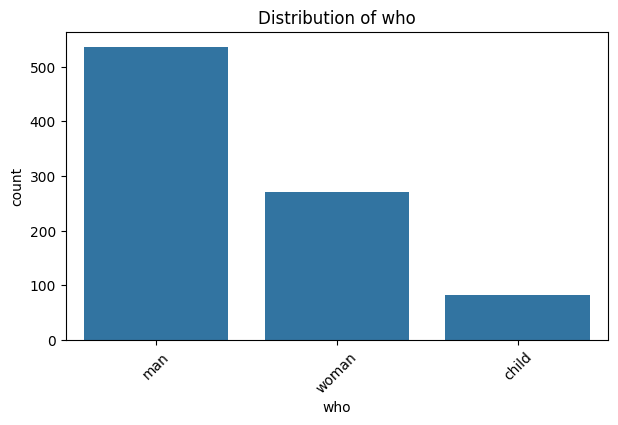

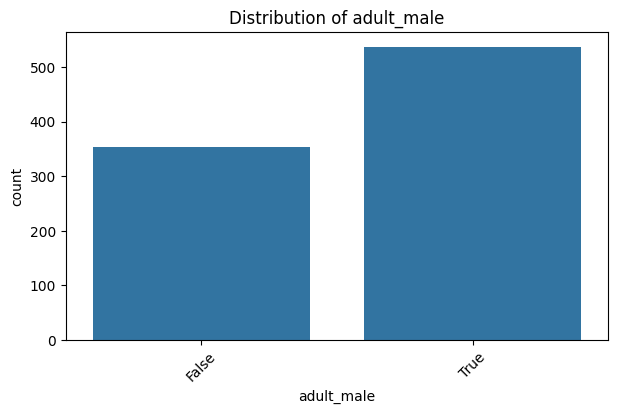

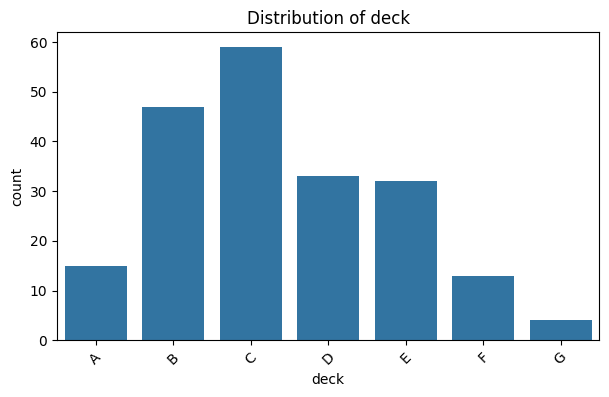

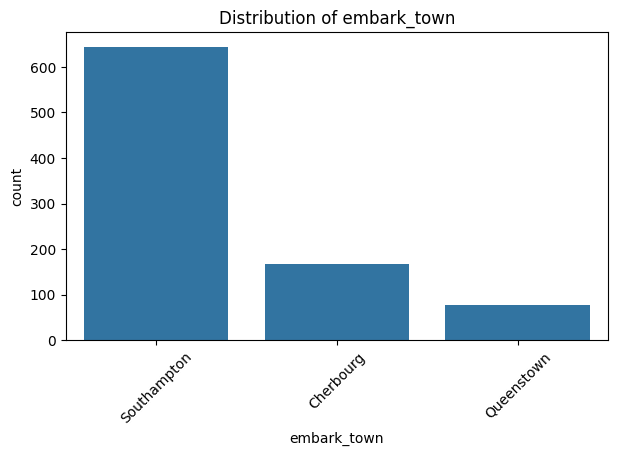

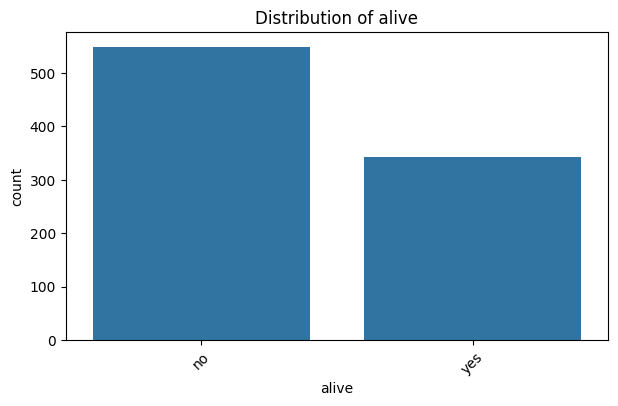

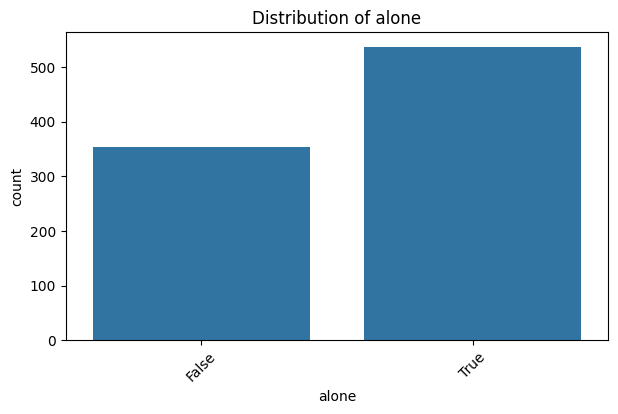

In [1641]:
for column in categorical_columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=45)
    plt.show()


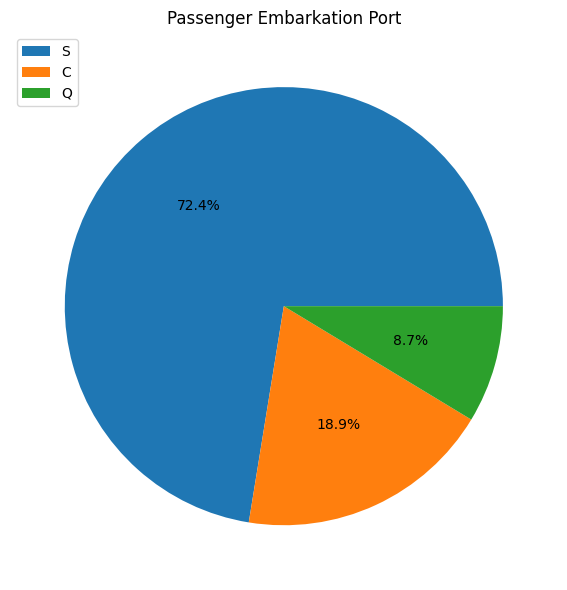

In [1642]:
import matplotlib.pyplot as plt

counts = df["embarked"].value_counts()

plt.figure(figsize=(7, 6))

plt.pie(
    counts.values,
    autopct="%0.1f%%",
)

plt.legend(
    counts.index,
    loc="upper left"
)

plt.title("Passenger Embarkation Port")

plt.tight_layout()
plt.show()

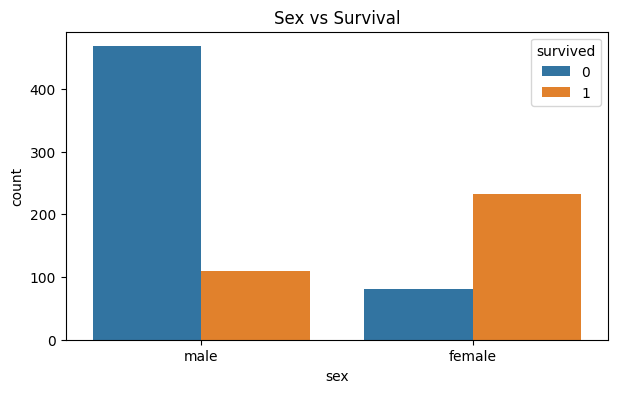

In [1643]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Sex vs Survival")
plt.show()


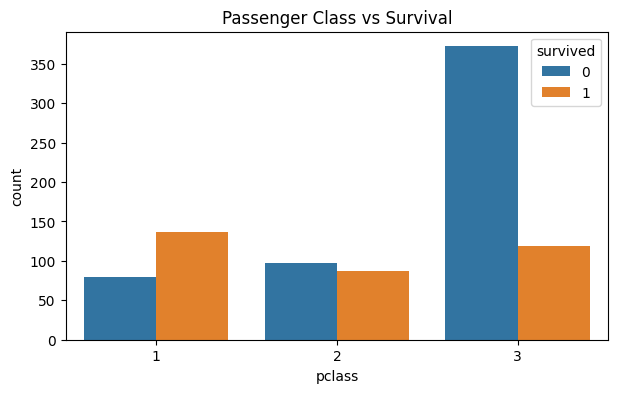

In [1644]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="pclass", hue="survived")
plt.title("Passenger Class vs Survival")
plt.show()


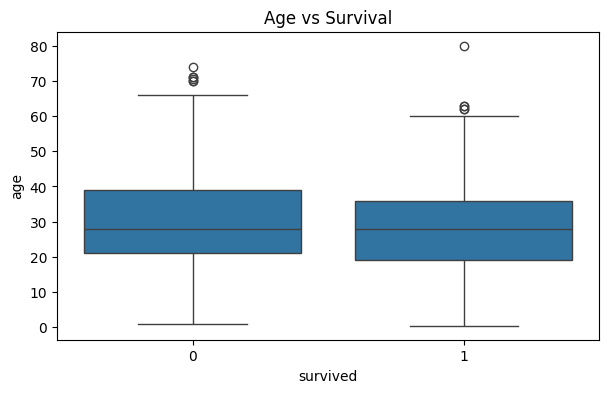

In [1645]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age vs Survival")
plt.show()


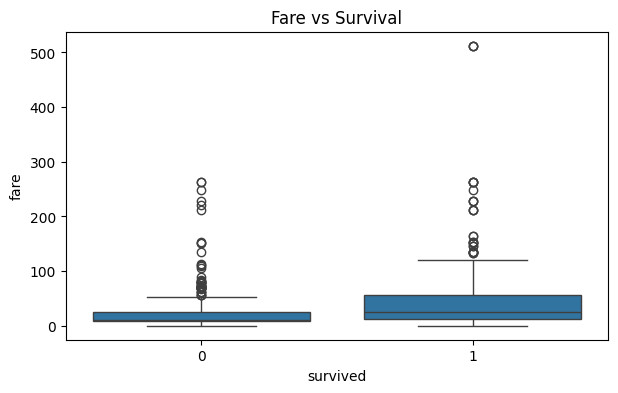

In [1646]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare vs Survival")
plt.show()


# Correlation Analysis

In [1647]:
correlation = df.corr(numeric_only=True)
correlation


,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


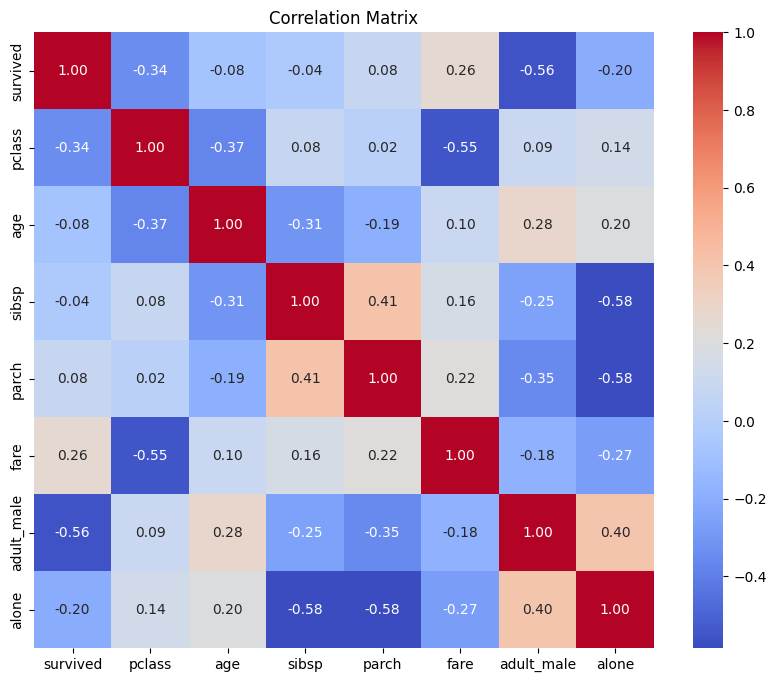

In [1648]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation,annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


**Reminder:** correlation measures association; it does not prove causation.

# Cleaning

In [1649]:
# Preserve the original dataset
data = df.copy()
print("Raw shape:", data.shape)


Raw shape: (891, 15)


# Handle Excessive Missingness

For this introductory lab, `deck` is removed because it contains a large proportion of missing values. In real projects, this decision should also consider domain knowledge and whether meaningful imputation is possible.

#drop()

Remove columns:

df.drop(columns=["deck"])

By default this creates a new DataFrame; it does not modify df.

To modify directly:

df.drop(columns=["deck"], inplace=True)

In [1650]:
data.drop(columns=["deck"], inplace=True)
print("Shape after dropping deck:", data.shape)


Shape after dropping deck: (891, 14)


#rename()

Change column names:

In [1651]:
df.rename(
    columns={"fare": "ticket_fare"}
)

,survived,pclass,sex,age,sibsp,parch,ticket_fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [1652]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [1653]:
''''df=df.rename(
    columns={"fare": "ticket_fare"}
)'''

'\'df=df.rename(\n    columns={"fare": "ticket_fare"}\n)'

In [1654]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Numerical Missing Values

Use median imputation for `age`. Median is less sensitive to extreme values than the mean.

In [1655]:
age_median = data["age"].median()
data["age"] = data["age"].fillna(age_median)

print("Median used:", age_median)


Median used: 28.0


# Categorical Missing Values

Use the mode for `embarked` and `embark_town`.

In [1656]:
embarked_mode = data["embarked"].mode()[0]
embark_town_mode = data["embark_town"].mode()[0]

data["embarked"] = data["embarked"].fillna(embarked_mode)
data["embark_town"] = data["embark_town"].fillna(embark_town_mode)

print("Embarked mode:", embarked_mode)
print("Embark town mode:", embark_town_mode)


Embarked mode: S
Embark town mode: Southampton


In [1657]:
data.isnull().sum()


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


#  Remove Duplicates

In [1658]:
print("Duplicates before:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Duplicates after :", data.duplicated().sum())
print("Current shape    :", data.shape)


Duplicates before: 116
Duplicates after : 0
Current shape    : (775, 14)


# Remove  Redundant features



- `alive` must be removed because it directly represents the target `survived`.
- `class` duplicates `pclass`.
- `embark_town` duplicates `embarked`.

This prevents leakage and unnecessary duplicate information.


In [1659]:
columns_to_remove = ["alive", "class", "embark_town"]

data.drop(columns=columns_to_remove, inplace=True)

print("Remaining columns:")
print(data.columns.tolist())


Remaining columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'adult_male', 'alone']


# Encode Categorical Variables

In [1660]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,True


In [1661]:


from sklearn.preprocessing import OneHotEncoder

categorical_to_encode = ["sex", "embarked", "who"]


ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)


encoded_array = ohe.fit_transform(
    data[categorical_to_encode]
)


encoded_columns = ohe.get_feature_names_out(  #get_feature_names_out() automatically generates these names for encoded columns.
    categorical_to_encode
)


encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=data.index  #It tells Pandas to Use the same row index as the original data DataFrame.
)


data.drop(
    columns=categorical_to_encode,
    inplace=True
)


data = pd.concat(
    [data, encoded_df],
    axis=1
)

print("Shape after encoding:", data.shape)

data.head()

Shape after encoding: (775, 16)


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman
0,0,3,22.0,1,0,7.2500,True,False,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1,1,38.0,1,0,71.2833,False,False,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,3,26.0,0,0,7.9250,False,True,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,False,False,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,True,True,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0



 # handle_unknown="ignore"

 The encoder will not throw an error because of the unseen category. If a category appears later that was not seen when the encoder was fitted, do not produce an error.




# sparse_output=False

This controls the format of the encoded output.

By default, OneHotEncoder can return a sparse matrix.

For teaching and normal DataFrame manipulation, we want a normal dense array.


#What does fit() mean?

fit() means:

Learn the categories present in the data.



#What does transform() mean?

transform() means:

Use the learned categories to convert categorical values into numerical values.

For example:

sex = female

could become:

sex_female = 1
sex_male   = 0



#What does fit_transform() mean?

Instead of writing:

ohe.fit(data[categorical_to_encode])

encoded_array = ohe.transform(
    data[categorical_to_encode]
)

we can combine both operations:

ohe.fit_transform(
    data[categorical_to_encode]
)

So:

fit_transform() = learn the categories + transform the data.




In [1662]:
boolean_columns = data.select_dtypes(include="bool").columns.tolist()
print("Boolean columns:", boolean_columns)


Boolean columns: ['adult_male', 'alone']


In [1663]:
for column in boolean_columns:
    data[column] = data[column].astype(int)

print(data.dtypes)


survived        int64
pclass          int64
age           float64
sibsp           int64
parch           int64
fare          float64
adult_male      int64
alone           int64
sex_female    float64
sex_male      float64
embarked_C    float64
embarked_Q    float64
embarked_S    float64
who_child     float64
who_man       float64
who_woman     float64
dtype: object


# Feature Scaling

Standardization:

```text
z = (x - mean) / standard deviation
```

After standardization, the transformed feature has approximately mean 0 and standard deviation 1.

For a real modeling workflow, the scaler should be fitted on training data only. Here we are only preparing a standalone cleaned dataset and are not training a model.


In [1664]:
from sklearn.preprocessing import StandardScaler

scale_columns = ["age", "fare"]

scaler = StandardScaler()
data[scale_columns] = scaler.fit_transform(data[scale_columns])

print("Scaling completed.")


Scaling completed.


In [1665]:
data[scale_columns].describe()


,age,fare
count,7.750000e+02,7.750000e+02
mean,2.521281e-16,-1.134576e-16
std,1.000646e+00,1.000646e+00
min,-2.119661e+00,-6.659405e-01
25%,-6.237473e-01,-5.122402e-01
50%,-1.149330e-01,-3.623586e-01
75%,4.665691e-01,-1.299298e-02
max,3.664831e+00,9.116066e+00


# Data Validation

In [1666]:
print("Final shape:", data.shape)


Final shape: (775, 16)


In [1667]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    775 non-null    int64  
 1   pclass      775 non-null    int64  
 2   age         775 non-null    float64
 3   sibsp       775 non-null    int64  
 4   parch       775 non-null    int64  
 5   fare        775 non-null    float64
 6   adult_male  775 non-null    int64  
 7   alone       775 non-null    int64  
 8   sex_female  775 non-null    float64
 9   sex_male    775 non-null    float64
 10  embarked_C  775 non-null    float64
 11  embarked_Q  775 non-null    float64
 12  embarked_S  775 non-null    float64
 13  who_child   775 non-null    float64
 14  who_man     775 non-null    float64
 15  who_woman   775 non-null    float64
dtypes: float64(10), int64(6)
memory usage: 102.9 KB


In [1668]:
final_missing = data.isnull().sum()
print(final_missing)
print("Total missing values:", final_missing.sum())


survived      0
pclass        0
age           0
sibsp         0
parch         0
fare          0
adult_male    0
alone         0
sex_female    0
sex_male      0
embarked_C    0
embarked_Q    0
embarked_S    0
who_child     0
who_man       0
who_woman     0
dtype: int64
Total missing values: 0


In [1669]:
print("Duplicate rows:", data.duplicated().sum())


Duplicate rows: 0


In [1670]:
non_numeric_columns = data.select_dtypes(exclude=np.number).columns.tolist()
print("Remaining non-numeric columns:", non_numeric_columns)


Remaining non-numeric columns: []


In [1671]:
df['familly_size']=df['sibsp']+df['parch']+1
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,familly_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1


In [1672]:
df['indvidual_fare']=df['fare']/df['familly_size']


In [1673]:
df[['indvidual_fare' , 'fare']].describe()

,indvidual_fare,fare
count,891.000000,891.000000
mean,19.916375,32.204208
std,35.841257,49.693429
min,0.000000,0.000000
25%,7.250000,7.910400
50%,8.300000,14.454200
75%,23.666667,31.000000
max,512.329200,512.329200


In [1674]:
data.head()


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman
0,0,3,-0.551060,1,0,-0.527515,1,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1,1,0.611945,1,0,0.695086,0,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,3,-0.260308,0,0,-0.514627,0,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,0.393881,1,0,0.347909,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0,3,0.393881,0,0,-0.512240,1,1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


# Create Final Feature Matrix and Target

Separate the inputs and target.




In [1675]:
X = data.drop(columns=["survived"])
y = data["survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (775, 15)
y shape: (775,)


In [1676]:
print("Final features:")
print(X.columns.tolist())


Final features:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman']


# Final Result

The dataset has reached the intended endpoint:

```text
Raw Dataset
     ↓
EDA
     ↓
Missing Value Analysis
     ↓
Distribution & Outlier Analysis
     ↓
Relationship Analysis
     ↓
Missing Value Handling
     ↓
Duplicate Handling
     ↓
Leakage / Redundancy Removal
     ↓
Categorical Encoding
     ↓
Scaling
     ↓
Final Validation
     ↓
CLEAN DATA
     ↓
READY FOR MODEL BUILDING
```

